In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# =========================
# ✅ Mac 한글 폰트 설정
# =========================
plt.rcParams["font.family"] = "AppleGothic"      # 맥 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 깨짐 방지


In [2]:
FILES = [
    ("202302_202304", "TPS_cancel_202302_202304_p_mt.csv"),
    ("202305_202307", "TPS_cancel_202305_202307_p_mt.csv"),
    ("202308_202310", "TPS_cancel_202308_202310_p_mt.csv"),
    ("202311_202312", "TPS_cancel_202311_202312_p_mt.csv"),
]


In [3]:
import pandas as pd

use_cols = ["SVC_USE_DAYS_GRP", "CH_HH_AVG_MONTH1"]  # 필요하면 p_mt 같은 컬럼 추가 가능

dfs = []
for period, path in FILES:
    df = pd.read_csv(path, usecols=use_cols)
    df["period"] = period
    dfs.append(df)

df_all_raw = pd.concat(dfs, ignore_index=True)

print("✅ df_all_raw shape:", df_all_raw.shape)
df_all_raw.head()


✅ df_all_raw shape: (19340213, 3)


,SVC_USE_DAYS_GRP,CH_HH_AVG_MONTH1,period
0,36개월 이상,8.17,202302_202304
1,6개월미만,2.41,202302_202304
2,36개월 이상,0.85,202302_202304
3,6개월~12개월미만,2.92,202302_202304
4,36개월 이상,1.37,202302_202304


In [4]:
import numpy as np

# 1) 빈 문자열 / 공백 문자열을 NaN으로 통일
df_tmp = df_all_raw.replace(r'^\s*$', np.nan, regex=True)

# 2) NaN 포함 행 전부 삭제
df_clean = df_tmp.dropna().reset_index(drop=True)

# 3) 삭제 전/후 행 수 확인
print("삭제 전 행 수:", df_all_raw.shape[0])
print("삭제 후 행 수:", df_clean.shape[0])
print("삭제된 행 수:", df_all_raw.shape[0] - df_clean.shape[0])


삭제 전 행 수: 19340213
삭제 후 행 수: 19340211
삭제된 행 수: 2


In [5]:
import pandas as pd

# 1) 문제 되는 라벨만 정확히 치환
df_clean["SVC_USE_DAYS_GRP"] = (
    df_clean["SVC_USE_DAYS_GRP"]
    .astype(str)
    .str.strip()
    .str.replace("24개월~ 36개월미만", "24개월~36개월미만", regex=False)
)

# 2) 순서 정의
order = [
    "6개월미만",
    "6개월~12개월미만",
    "12개월~24개월미만",
    "24개월~36개월미만",
    "36개월 이상"
]

# 3) 순서형 범주화
df_clean["SVC_USE_DAYS_GRP"] = pd.Categorical(
    df_clean["SVC_USE_DAYS_GRP"],
    categories=order,
    ordered=True
)

# 4) 검증
print("라벨 분포:")
print(df_clean["SVC_USE_DAYS_GRP"].value_counts(dropna=False))


라벨 분포:
SVC_USE_DAYS_GRP
36개월 이상        13323767
12개월~24개월미만     1965959
24개월~36개월미만     1937077
6개월미만           1097124
6개월~12개월미만      1016284
Name: count, dtype: int64


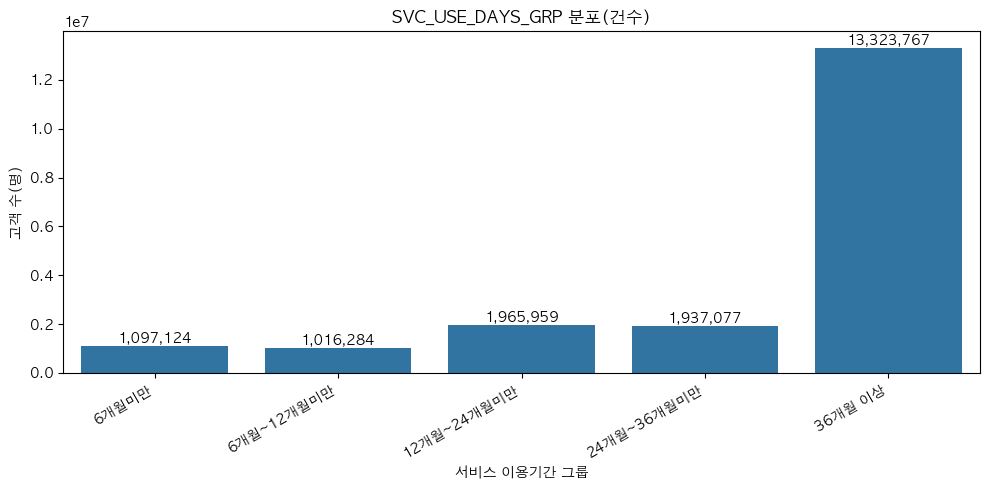

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_clean, x="SVC_USE_DAYS_GRP", order=order)

plt.title("SVC_USE_DAYS_GRP 분포(건수)")
plt.xlabel("서비스 이용기간 그룹")
plt.ylabel("고객 수(명)")
plt.xticks(rotation=30, ha="right")

# 막대 위에 건수 표시
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


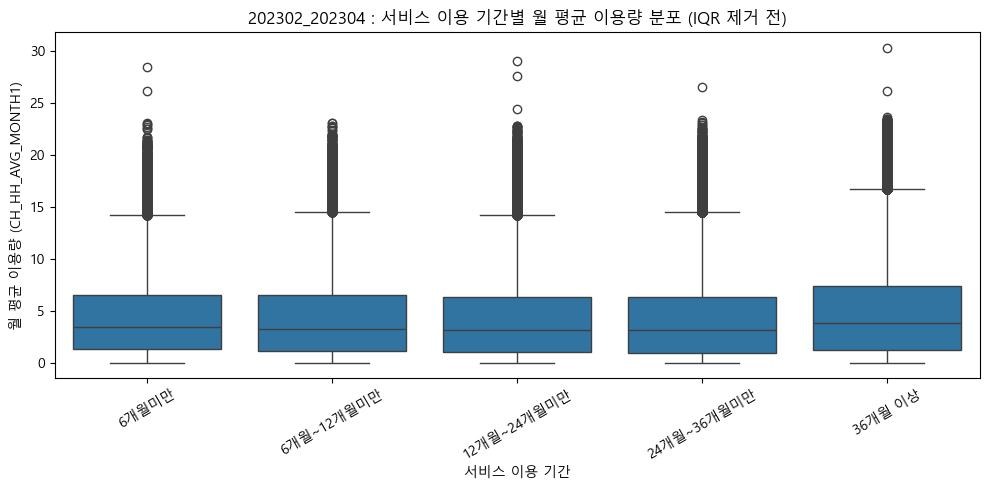

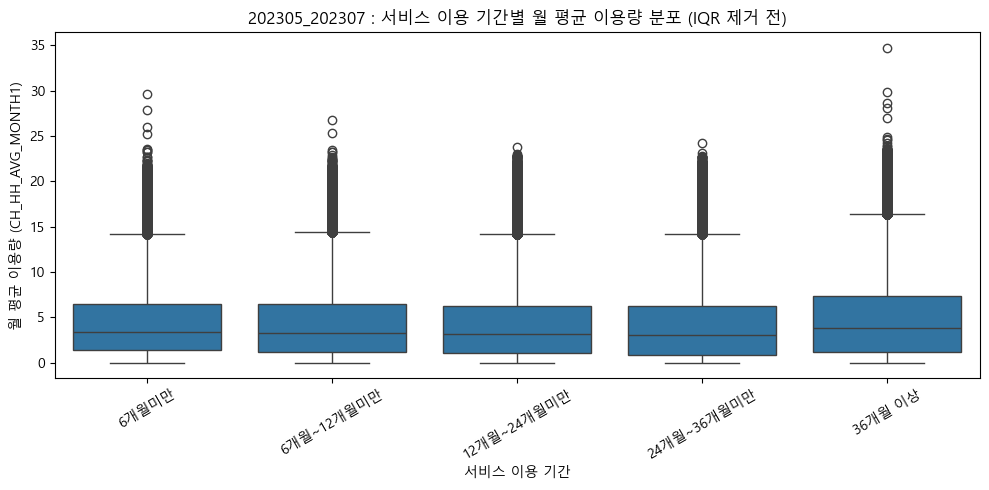

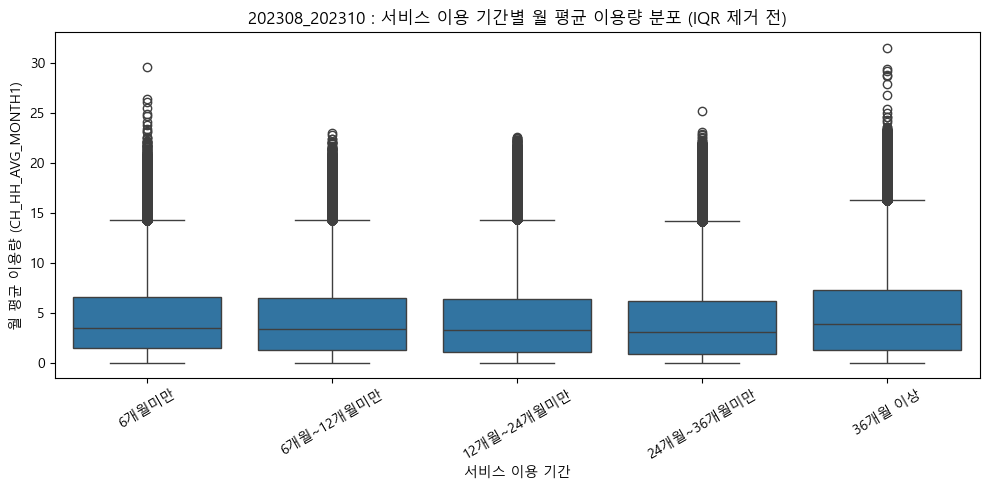

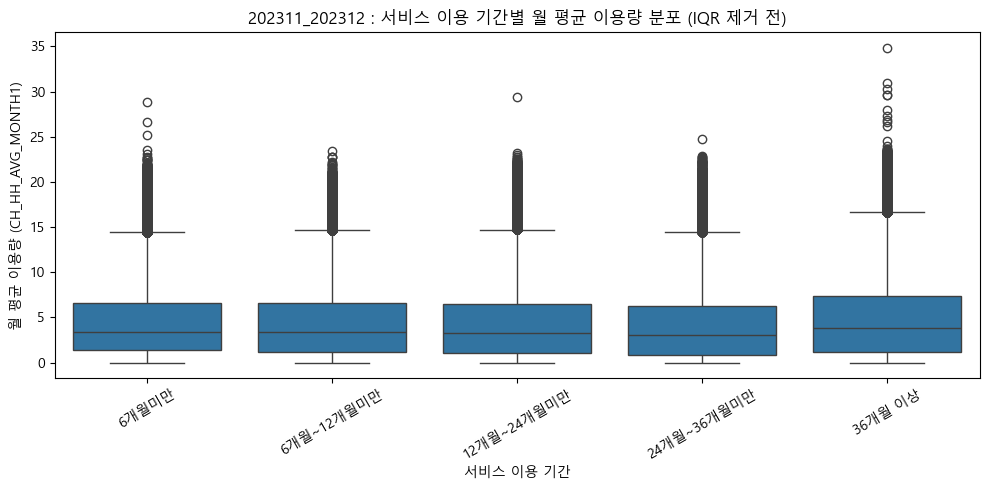

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

period_list = df_clean["period"].unique()

for p in period_list:
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        x="SVC_USE_DAYS_GRP",
        y="CH_HH_AVG_MONTH1",
        data=df_clean[df_clean["period"] == p],
        order=order,          # X축 순서 고정
        showfliers=True
    )
    plt.xticks(rotation=30)
    plt.title(f"{p} : 서비스 이용 기간별 월 평균 이용량 분포 (IQR 제거 전)")
    plt.xlabel("서비스 이용 기간")
    plt.ylabel("월 평균 이용량 (CH_HH_AVG_MONTH1)")
    plt.tight_layout()
    plt.show()


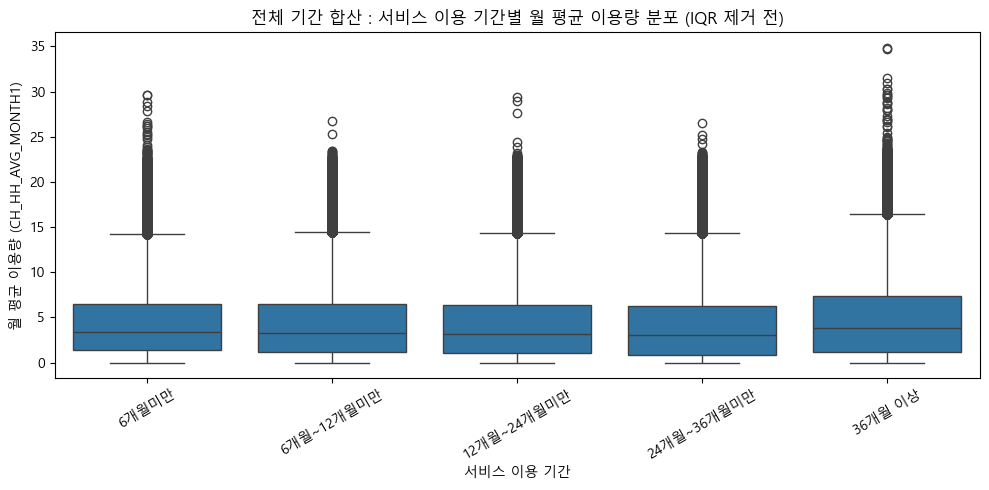

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    x="SVC_USE_DAYS_GRP",
    y="CH_HH_AVG_MONTH1",
    data=df_clean,
    order=order,              # X축 순서 고정
    showfliers=True
)
plt.xticks(rotation=30)
plt.title("전체 기간 합산 : 서비스 이용 기간별 월 평균 이용량 분포 (IQR 제거 전)")
plt.xlabel("서비스 이용 기간")
plt.ylabel("월 평균 이용량 (CH_HH_AVG_MONTH1)")
plt.tight_layout()
plt.show()


IQR 제거 전 행 수: 19340211
IQR 제거 후 행 수: 19102551
제거된 행 수: 237660


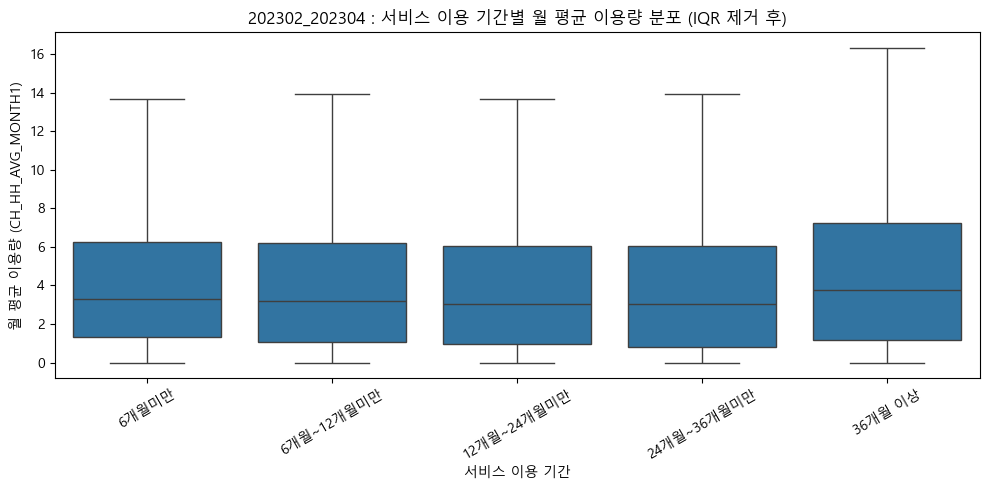

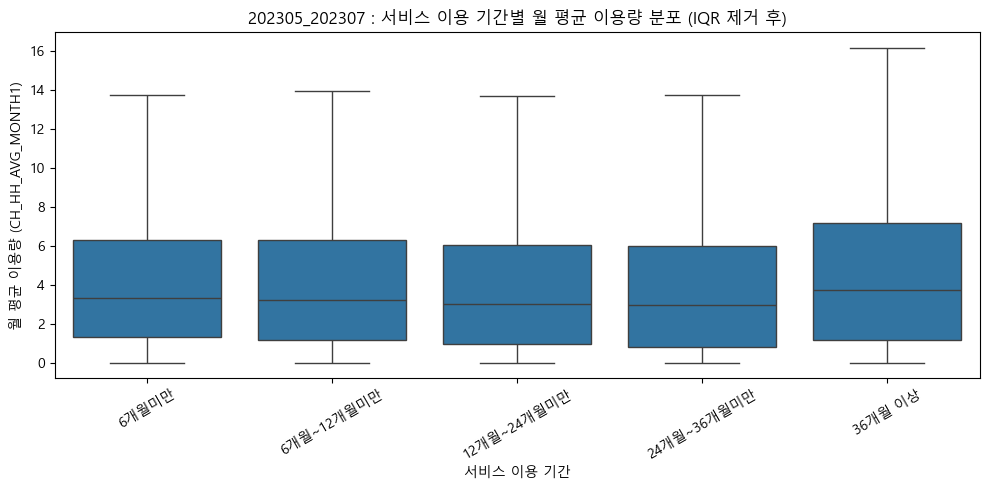

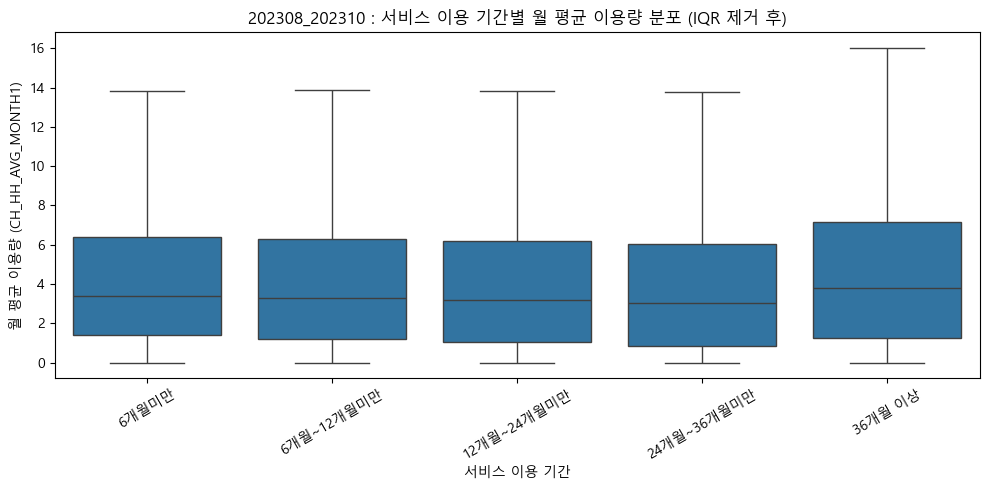

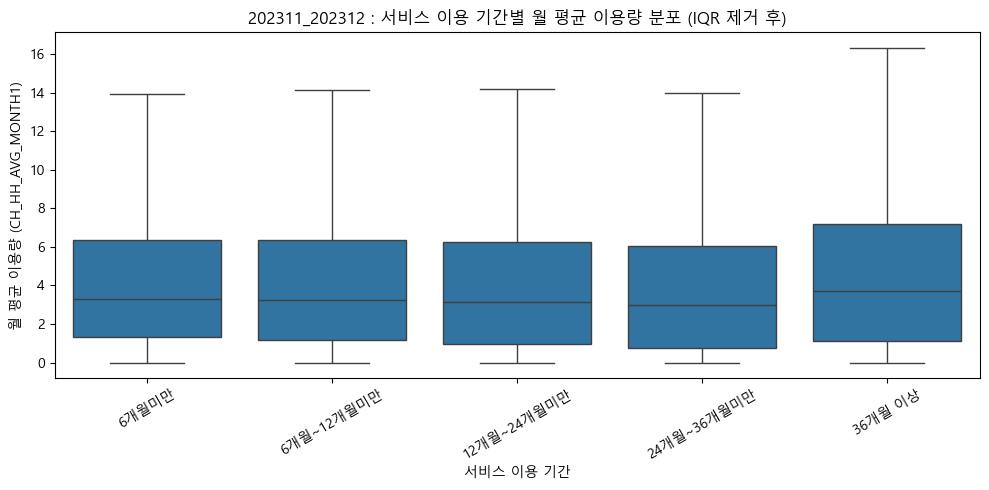

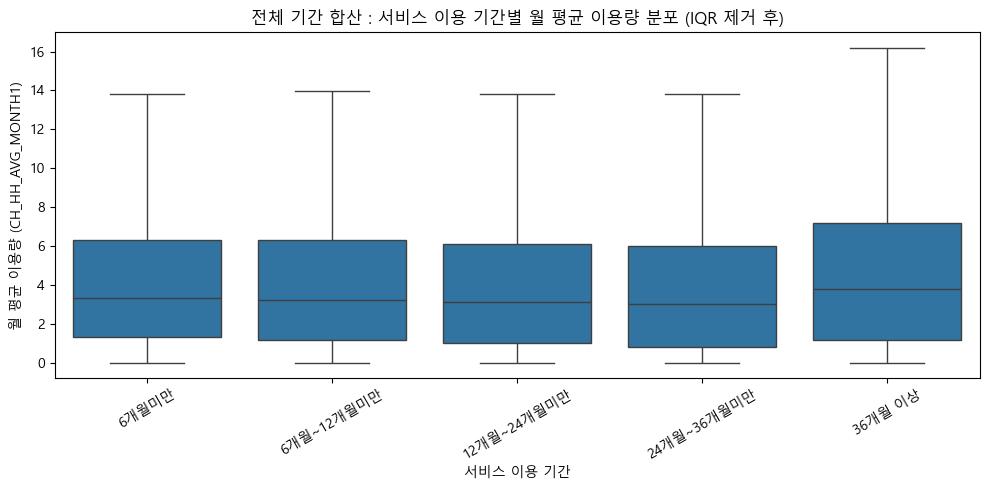

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1) 그룹별 IQR 이상치 제거 함수
# =========================
def remove_outliers_iqr_by_group(df, group_col, value_col):
    dfs = []
    for g, sub in df.groupby(group_col):
        if sub.empty:
            continue

        Q1 = sub[value_col].quantile(0.25)
        Q3 = sub[value_col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        filtered = sub[
            (sub[value_col] >= lower) &
            (sub[value_col] <= upper)
        ]
        dfs.append(filtered)

    return pd.concat(dfs, ignore_index=True)

# =========================
# 2) IQR 기준 이상치 제거 적용
# =========================
df_no_outlier = remove_outliers_iqr_by_group(
    df_clean,
    group_col="SVC_USE_DAYS_GRP",
    value_col="CH_HH_AVG_MONTH1"
)

print("IQR 제거 전 행 수:", df_clean.shape[0])
print("IQR 제거 후 행 수:", df_no_outlier.shape[0])
print("제거된 행 수:", df_clean.shape[0] - df_no_outlier.shape[0])

# =========================
# 3) 기간별 박스플롯 (IQR 제거 후)
# =========================
period_list = df_no_outlier["period"].unique()

for p in period_list:
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        x="SVC_USE_DAYS_GRP",
        y="CH_HH_AVG_MONTH1",
        data=df_no_outlier[df_no_outlier["period"] == p],
        order=order,
        showfliers=False
    )
    plt.xticks(rotation=30)
    plt.title(f"{p} : 서비스 이용 기간별 월 평균 이용량 분포 (IQR 제거 후)")
    plt.xlabel("서비스 이용 기간")
    plt.ylabel("월 평균 이용량 (CH_HH_AVG_MONTH1)")
    plt.tight_layout()
    plt.show()

# =========================
# 4) 전체 기간 합산 박스플롯 (IQR 제거 후)
# =========================
plt.figure(figsize=(10, 5))
sns.boxplot(
    x="SVC_USE_DAYS_GRP",
    y="CH_HH_AVG_MONTH1",
    data=df_no_outlier,
    order=order,
    showfliers=False
)
plt.xticks(rotation=30)
plt.title("전체 기간 합산 : 서비스 이용 기간별 월 평균 이용량 분포 (IQR 제거 후)")
plt.xlabel("서비스 이용 기간")
plt.ylabel("월 평균 이용량 (CH_HH_AVG_MONTH1)")
plt.tight_layout()
plt.show()


In [11]:
summary_table = (
    df_no_outlier
    .groupby("SVC_USE_DAYS_GRP")["CH_HH_AVG_MONTH1"]
    .agg(
        count="count",
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Q3=lambda x: x.quantile(0.75),
        Mean="mean"
    )
    .reset_index()
)

summary_table


,SVC_USE_DAYS_GRP,count,Q1,Median,Q3,Mean
0,6개월미만,1077859,1.33,3.34,6.32,4.140122
1,6개월~12개월미만,999063,1.16,3.24,6.28,4.062165
2,12개월~24개월미만,1930480,0.99,3.09,6.12,3.930012
3,24개월~36개월미만,1903379,0.81,3.00,6.02,3.833884
4,36개월 이상,13191770,1.18,3.76,7.18,4.577956


In [12]:
df_no_outlier.groupby("SVC_USE_DAYS_GRP")["CH_HH_AVG_MONTH1"].describe()


,count,mean,std,min,25%,50%,75%,max
SVC_USE_DAYS_GRP,,,,,,,,
6개월미만,1077859.0,4.140122,3.484715,0.0,1.33,3.34,6.32,14.27
6개월~12개월미만,999063.0,4.062165,3.551288,0.0,1.16,3.24,6.28,14.44
12개월~24개월미만,1930480.0,3.930012,3.536106,0.0,0.99,3.09,6.12,14.32
24개월~36개월미만,1903379.0,3.833884,3.531483,0.0,0.81,3.00,6.02,14.31
36개월 이상,13191770.0,4.577956,3.999387,0.0,1.18,3.76,7.18,16.45


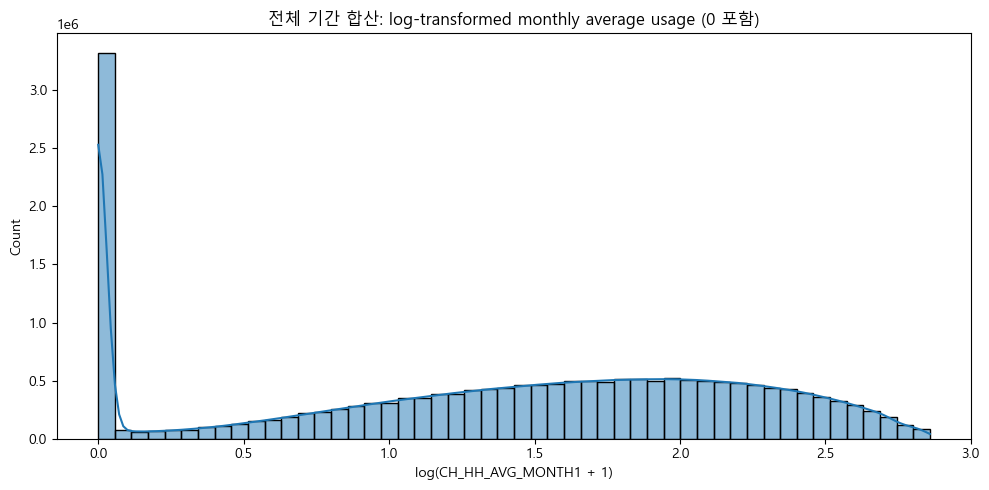

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 데이터 그대로 사용 (0 이용 고객 포함)
df_pos = df_no_outlier.copy()

# 로그 변환 (log1p → 0도 안전)
df_pos["log_CH_HH_AVG_MONTH1"] = np.log1p(df_pos["CH_HH_AVG_MONTH1"])

plt.figure(figsize=(10, 5))
sns.histplot(df_pos["log_CH_HH_AVG_MONTH1"], bins=50, kde=True)
plt.title("전체 기간 합산: log-transformed monthly average usage (0 포함)")
plt.xlabel("log(CH_HH_AVG_MONTH1 + 1)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


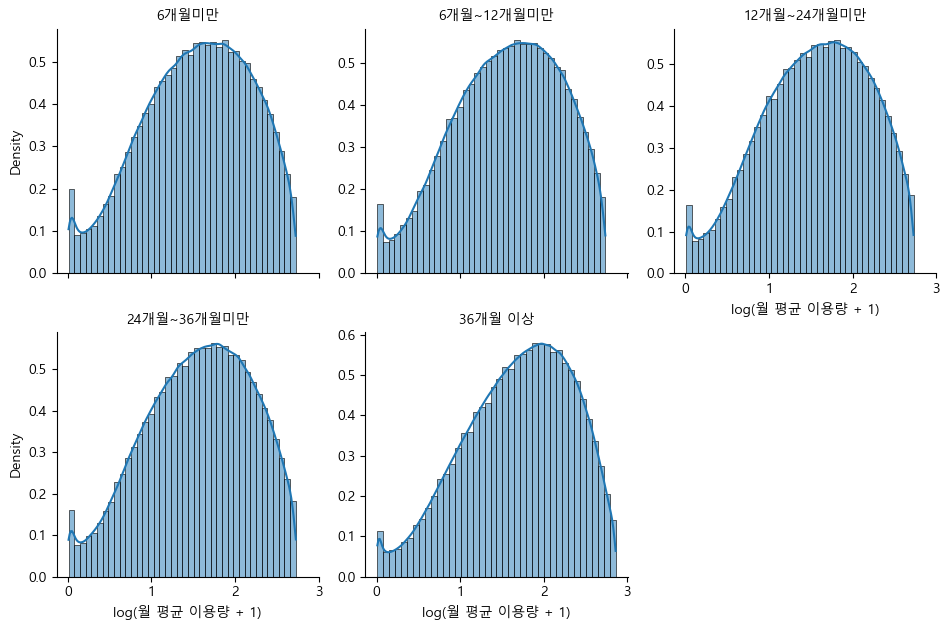

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) 0 이용 고객 제거
df_pos = df_no_outlier[df_no_outlier["CH_HH_AVG_MONTH1"] > 0].copy()

# 2) 로그 변환
df_pos["log_CH_HH_AVG_MONTH1"] = np.log1p(df_pos["CH_HH_AVG_MONTH1"])

# 3) 서비스 이용 기간 순서 고정
order = [
    "6개월미만",
    "6개월~12개월미만",
    "12개월~24개월미만",
    "24개월~36개월미만",
    "36개월 이상"
]

df_pos["SVC_USE_DAYS_GRP"] = pd.Categorical(
    df_pos["SVC_USE_DAYS_GRP"],
    categories=order,
    ordered=True
)

# 4) 그룹별 히스토그램 (FacetGrid)
g = sns.FacetGrid(
    df_pos,
    col="SVC_USE_DAYS_GRP",
    col_order=order,
    col_wrap=3,
    height=3.2,
    sharex=True,
    sharey=False
)

g.map_dataframe(
    sns.histplot,
    x="log_CH_HH_AVG_MONTH1",
    bins=40,
    stat="density",
    kde=True
)

g.set_axis_labels("log(월 평균 이용량 + 1)", "Density")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1) Welch ANOVA용 데이터 준비
df_anova = df_pos[[
    "SVC_USE_DAYS_GRP",
    "log_CH_HH_AVG_MONTH1"
]].dropna().copy()

# 순서형 범주 유지
order = [
    "6개월미만",
    "6개월~12개월미만",
    "12개월~24개월미만",
    "24개월~36개월미만",
    "36개월 이상"
]

df_anova["SVC_USE_DAYS_GRP"] = pd.Categorical(
    df_anova["SVC_USE_DAYS_GRP"],
    categories=order,
    ordered=True
)

# 2) Welch ANOVA (heteroscedasticity robust)
model = smf.ols(
    "log_CH_HH_AVG_MONTH1 ~ C(SVC_USE_DAYS_GRP)",
    data=df_anova
).fit()

anova_welch = sm.stats.anova_lm(model, typ=2, robust="hc3")
anova_welch


,sum_sq,df,F,PR(>F)
C(SVC_USE_DAYS_GRP),6.200636e+04,4.0,38364.134495,0.0
Residual,6.419851e+06,15888178.0,NaN,NaN


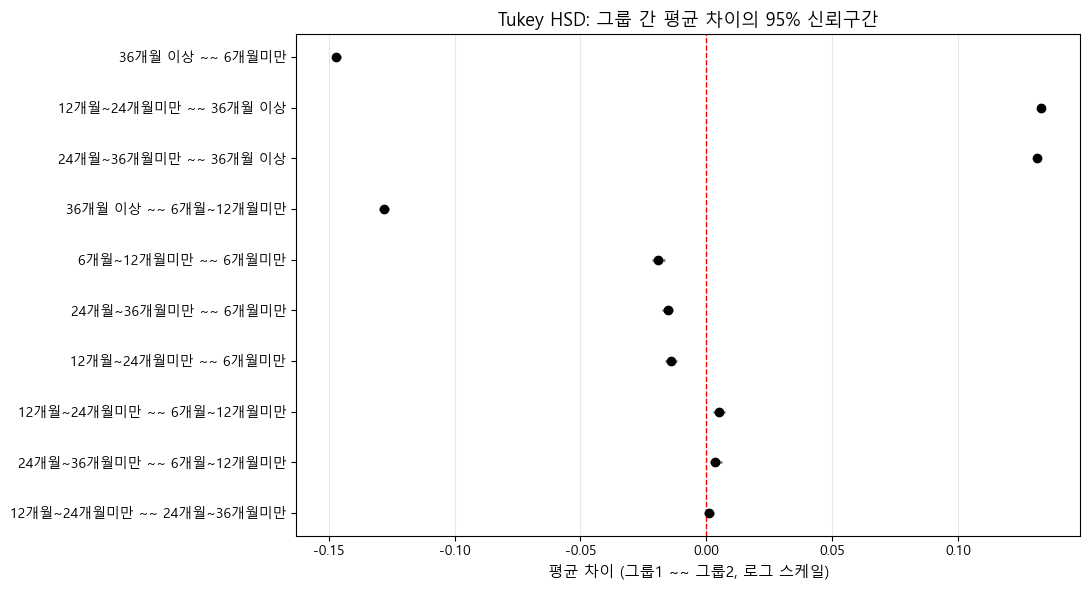

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
12개월~24개월미만 24개월~36개월미만   0.0013  0.368 -0.0007  0.0032  False
12개월~24개월미만     36개월 이상   0.1329    0.0  0.1315  0.1344   True
12개월~24개월미만  6개월~12개월미만    0.005    0.0  0.0027  0.0073   True
12개월~24개월미만       6개월미만   -0.014    0.0 -0.0162 -0.0117   True
24개월~36개월미만     36개월 이상   0.1316    0.0  0.1301  0.1331   True
24개월~36개월미만  6개월~12개월미만   0.0037 0.0001  0.0014  0.0061   True
24개월~36개월미만       6개월미만  -0.0153    0.0 -0.0175  -0.013   True
    36개월 이상  6개월~12개월미만  -0.1279    0.0 -0.1299  -0.126   True
    36개월 이상       6개월미만  -0.1469    0.0 -0.1487  -0.145   True
 6개월~12개월미만       6개월미만   -0.019    0.0 -0.0216 -0.0164   True
--------------------------------------------------------------


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ✅ Tukey에 넣을 컬럼 확인 (여기서는 월평균 이용량 로그 변환)
y_col = "log_CH_HH_AVG_MONTH1"
g_col = "SVC_USE_DAYS_GRP"

# (안전) 결측 제거
df_tukey = df_anova[[g_col, y_col]].dropna().copy()

# 1) Tukey HSD
tukey = pairwise_tukeyhsd(
    endog=df_tukey[y_col],
    groups=df_tukey[g_col],
    alpha=0.05
)

# 2) 결과 추출
rows = tukey.summary().data[1:]

labels   = [f"{r[0]} ~~ {r[1]}" for r in rows]
meandiff = np.array([float(r[2]) for r in rows])
lower    = np.array([float(r[4]) for r in rows])
upper    = np.array([float(r[5]) for r in rows])
reject   = np.array([bool(r[6]) for r in rows])  # 유의 여부

# 3) 절댓값 기준 정렬 (차이 큰 비교가 아래/위로 보기 좋게)
order_idx = np.argsort(np.abs(meandiff))

labels   = [labels[i] for i in order_idx]
meandiff = meandiff[order_idx]
lower    = lower[order_idx]
upper    = upper[order_idx]
reject   = reject[order_idx]

y = np.arange(len(labels))

# 4) Plot
plt.figure(figsize=(11, 6))

# 신뢰구간
plt.hlines(y=y, xmin=lower, xmax=upper, color="gray", linewidth=2)

# 평균 차이 점 (유의하면 진하게/아니면 연하게 표시하고 싶으면 색을 나눠도 되지만,
# 지금은 기본 색만 유지)
plt.scatter(meandiff, y, color="black", zorder=3)

# 0 기준선
plt.axvline(0, color="red", linestyle="--", linewidth=1)

plt.yticks(y, labels, fontsize=10)
plt.xlabel("평균 차이 (그룹1 ~~ 그룹2, 로그 스케일)", fontsize=11)
plt.title("Tukey HSD: 그룹 간 평균 차이의 95% 신뢰구간", fontsize=13)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# (옵션) 표 형태로도 확인
print(tukey.summary())


In [19]:
from scipy.stats import ttest_ind

# 1) 36개월 이상
group_long = df_pos.loc[
    df_pos["SVC_USE_DAYS_GRP"] == "36개월 이상",
    "log_CH_HH_AVG_MONTH1"
]

# 2) 나머지 (36개월 미만)
group_others = df_pos.loc[
    df_pos["SVC_USE_DAYS_GRP"] != "36개월 이상",
    "log_CH_HH_AVG_MONTH1"
]

# 3) Welch t-test (등분산 가정 X)
t_stat, p_value = ttest_ind(
    group_long,
    group_others,
    equal_var=False
)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")


t-statistic: 391.23275506666835
p-value: 0.0


In [8]:
import pandas as pd

# parquet 로드
df_sha = pd.read_parquet("sha_df.parquet")

# ✅ 컬럼명 전체 출력
print("=== columns ===")
print(df_sha.columns.tolist())

# ✅ 상위 5개 행 출력
print("\n=== head(5) ===")
display(df_sha.head(5))


=== columns ===
['고객ID', '기준년월', '해지여부', '연령대', '가입기간', '총사용일수', '만료잔여기간', '약정만료일', '구형장비여부', '최근1달_셋톱장애경험', '최근1달_민원접수', '최근1달_해지방어', '유튜브_사용여부', '넷플릭스_사용여부', '월평균시청시간', '재택비율', '마지막시청_경과일', '키즈시청건수']

=== head(5) ===


,고객ID,기준년월,해지여부,연령대,가입기간,총사용일수,만료잔여기간,약정만료일,구형장비여부,최근1달_셋톱장애경험,최근1달_민원접수,최근1달_해지방어,유튜브_사용여부,넷플릭스_사용여부,월평균시청시간,재택비율,마지막시청_경과일,키즈시청건수
0,6c2fb1fb0b1e316975157671e03d0e2eb3d250a7373321...,202303,유지,50대,6개월미만,45,약정만료전 12개월이상,20260213,N,N,Y,N,N,N,4.46,10.0,일주일내,2.0
1,39b9ff560dbcbe4e138f04fd082d55d921c5528f1cc279...,202303,유지,70대,6개월미만,45,약정만료전 12개월이상,20260213,N,N,Y,N,N,N,4.57,10.0,일주일내,1.0
2,db168b085b5c0cd2d21faab70ceb4ec36c5409aea1f8f4...,202303,유지,70대,6개월미만,44,약정만료전 12개월이상,20260214,N,N,Y,N,N,N,6.32,20.0,일주일내,0.0
3,59a02dfe6d4e5e4ffc1b295dc0ebf0fdf7ffc37321f653...,202303,유지,40대,6개월미만,3006,약정만료전 12개월이상,20260214,N,N,Y,N,N,N,1.18,0.0,일주일내,0.0
4,6f415993f9b6968f3b7bd8b2188f8651dfdc7e50e3022a...,202303,유지,60대,6개월미만,42,약정만료전 12개월이상,20260216,N,N,Y,N,Y,N,3.05,10.0,일주일내,0.0


In [9]:
import numpy as np
import pandas as pd

df_sha = pd.read_parquet("sha_df.parquet").copy()

# 1) period 만들기 (월 단위)
df_sha["period"] = df_sha["기준년월"].astype(str)

# 2) 해지여부를 0/1로 표준화 (유지=0, 해지=1)
df_sha["canceled"] = (df_sha["해지여부"] == "해지").astype(int)

# 3) 장기여부 (가입기간이 "36개월 이상"이면 장기)
df_sha["is_long_row"] = (df_sha["가입기간"] == "36개월 이상")

# 4) 고객-월(period) 단위로 중복 제거 + OR 처리
cust_period = (
    df_sha
    .groupby(["period", "고객ID"], as_index=False)
    .agg(
        is_long=("is_long_row", "max"),   # 기간 내 한번이라도 장기 조건이면 장기
        canceled=("canceled", "max")      # 기간 내 한번이라도 해지면 해지
    )
)

cust_period["grp"] = np.where(cust_period["is_long"], "long", "others")

# 중복 제거 검증
print("원본 행 수:", len(df_sha))
print("고객-월 단위 행 수:", len(cust_period))
print("중복( period+고객ID ):",
      cust_period.duplicated(["period", "고객ID"]).sum())


원본 행 수: 22893471
고객-월 단위 행 수: 22473534
중복( period+고객ID ): 0


In [10]:
summary = (
    cust_period
    .groupby(["period", "grp"], as_index=False)
    .agg(
        n_customers=("고객ID", "nunique"),
        n_canceled=("canceled", "sum")
    )
)

ok = summary.pivot(index="period", columns="grp", values=["n_customers", "n_canceled"])
ok.columns = [f"{a}_{b}" for a, b in ok.columns]
ok = ok.reset_index()

ok["n_long"] = ok.get("n_customers_long", 0)
ok["n_others"] = ok.get("n_customers_others", 0)

ok["long_canceled"] = ok.get("n_canceled_long", 0)
ok["others_canceled"] = ok.get("n_canceled_others", 0)

ok["long_not_canceled"] = ok["n_long"] - ok["long_canceled"]
ok["others_not_canceled"] = ok["n_others"] - ok["others_canceled"]

# 0으로 나누기 방지
ok = ok[(ok["n_long"] > 0) & (ok["n_others"] > 0)].copy()

ok["cancel_rate_long_%"] = ok["long_canceled"] / ok["n_long"] * 100
ok["cancel_rate_others_%"] = ok["others_canceled"] / ok["n_others"] * 100

print(ok.head())


   period  n_customers_long  n_customers_others  n_canceled_long  \
0  202302           1388901              660705           108779   
1  202303           1393474              654740           102102   
2  202304           1398705              648027            96096   
3  202305           1404096              642595            90336   
4  202306           1407029              638369            83099   

   n_canceled_others   n_long  n_others  long_canceled  others_canceled  \
0              73390  1388901    660705         108779            73390   
1              67441  1393474    654740         102102            67441   
2              61482  1398705    648027          96096            61482   
3              55773  1404096    642595          90336            55773   
4              49788  1407029    638369          83099            49788   

   long_not_canceled  others_not_canceled  cancel_rate_long_%  \
0            1280122               587315            7.832020   
1         

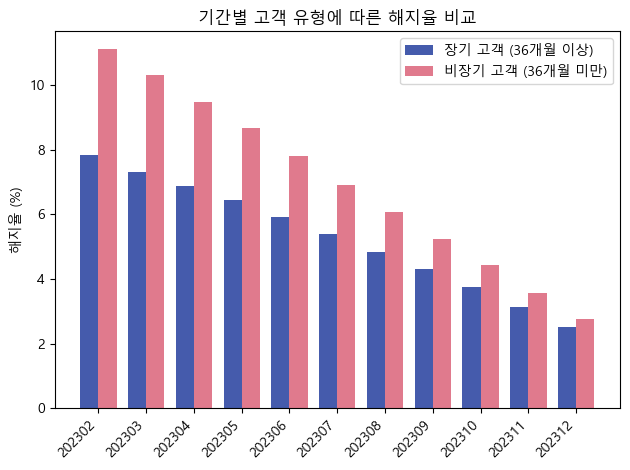

In [11]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

plot_df = ok.sort_values("period").reset_index(drop=True)

x = np.arange(len(plot_df))
periods = plot_df["period"].tolist()
w = 0.38

colors = ["#455BAC", "#E07A8D"]

plt.figure()
plt.bar(x - w/2, plot_df["cancel_rate_long_%"], width=w, label="장기 고객 (36개월 이상)", color=colors[0])
plt.bar(x + w/2, plot_df["cancel_rate_others_%"], width=w, label="비장기 고객 (36개월 미만)", color=colors[1])

plt.xticks(x, periods, rotation=45, ha="right")
plt.ylabel("해지율 (%)")
plt.title("기간별 고객 유형에 따른 해지율 비교")
plt.legend()
plt.tight_layout()
plt.show()


=== 전체 기간 통합 결과 (고객 단위, OR 처리) ===
2x2 table (grp_long x cancel_yn)
Others(<36m): NotCanceled=551140, Canceled=62205
Long(36m+):   NotCanceled=1433511, Canceled=128471

Long cancel rate:   8.2249%
Others cancel rate: 10.1419%
Diff: -1.917 %p
Relative reduction: 18.90 %
Chi-square p-value: 0


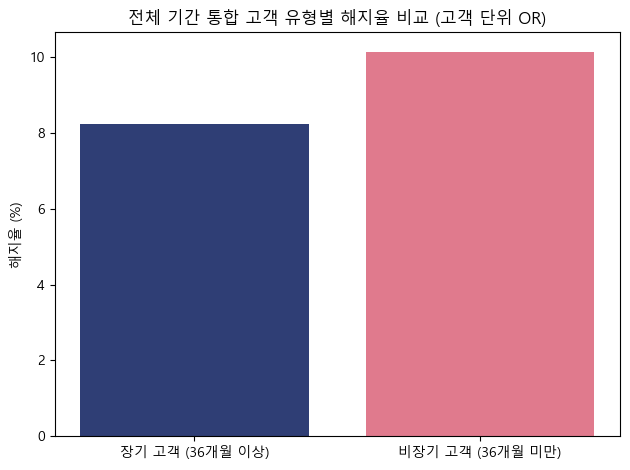

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

# =========================
# 0) df_sha 준비 (이미 로딩되어 있으면 생략 가능)
# =========================
# df_sha = pd.read_parquet("sha_df.parquet").copy()

# 필수 컬럼 체크
need_cols = ["고객ID", "해지여부", "가입기간"]
missing = [c for c in need_cols if c not in df_sha.columns]
if missing:
    raise ValueError(f"필수 컬럼이 없습니다: {missing}")

# =========================
# 1) 해지여부/장기여부 표준화
# =========================
df_tmp = df_sha.copy()
df_tmp["canceled"] = (df_tmp["해지여부"] == "해지").astype(int)
df_tmp["is_long_row"] = (df_tmp["가입기간"] == "36개월 이상")

# =========================
# 2) 전체 기간 통합: 고객 단위 OR 처리
#    - canceled: 한번이라도 해지면 1
#    - is_long:  전체 기간 중 한번이라도 36개월 이상이면 장기
# =========================
cust_total = (
    df_tmp
    .groupby("고객ID", as_index=False)
    .agg(
        is_long=("is_long_row", "max"),
        canceled=("canceled", "max")
    )
)

# 집단별 카운트
long_canceled = cust_total[(cust_total["is_long"] == 1) & (cust_total["canceled"] == 1)].shape[0]
long_not      = cust_total[(cust_total["is_long"] == 1) & (cust_total["canceled"] == 0)].shape[0]

oth_canceled  = cust_total[(cust_total["is_long"] == 0) & (cust_total["canceled"] == 1)].shape[0]
oth_not       = cust_total[(cust_total["is_long"] == 0) & (cust_total["canceled"] == 0)].shape[0]

# 해지율
rate_long = long_canceled / (long_canceled + long_not)
rate_oth  = oth_canceled / (oth_canceled + oth_not)

diff_pp = (rate_long - rate_oth) * 100
relative_reduction = (rate_oth - rate_long) / rate_oth * 100 if rate_oth > 0 else np.nan

# 2x2 + 카이제곱
ct = np.array([
    [oth_not,  oth_canceled],
    [long_not, long_canceled]
])

chi2, p_value, dof, exp = chi2_contingency(ct)

print("=== 전체 기간 통합 결과 (고객 단위, OR 처리) ===")
print("2x2 table (grp_long x cancel_yn)")
print(f"Others(<36m): NotCanceled={ct[0,0]}, Canceled={ct[0,1]}")
print(f"Long(36m+):   NotCanceled={ct[1,0]}, Canceled={ct[1,1]}\n")

print(f"Long cancel rate:   {rate_long:.4%}")
print(f"Others cancel rate: {rate_oth:.4%}")
print(f"Diff: {diff_pp:.3f} %p")
print(f"Relative reduction: {relative_reduction:.2f} %")
print(f"Chi-square p-value: {p_value:.3g}")

# =========================
# 3) 전체 통합 막대그래프
# =========================
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

labels = ["장기 고객 (36개월 이상)", "비장기 고객 (36개월 미만)"]
rates  = [rate_long * 100, rate_oth * 100]
colors = ["#2F3E75", "#E07A8D"]

plt.figure()
plt.bar(labels, rates, color=colors)
plt.ylabel("해지율 (%)")
plt.title("전체 기간 통합 고객 유형별 해지율 비교 (고객 단위 OR)")
plt.tight_layout()
plt.show()


In [ ]:
# # 기간별 해지율 비교 (장기 VS 비장기)
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm
# import warnings
# warnings.filterwarnings('ignore')

# # 한글 폰트 설정 (Windows)
# font_path = 'C:/Windows/Fonts/malgun.ttf'
# font_prop = fm.FontProperties(fname=font_path)

# plt.rcParams['font.family'] = font_prop.get_name()
# plt.rcParams['axes.unicode_minus'] = False

# # 데이터 정렬
# plot_df = ok.sort_values("period").reset_index(drop=True)

# x = np.arange(len(plot_df))
# periods = plot_df["period"].tolist()
# w = 0.38

# # 🎨 색상 지정 (요청한 조합)
# colors = ["#455BAC", "#E07A8D"]  # 네이비 / 더스티 핑크

# plt.figure()
# plt.bar(
#     x - w/2,
#     plot_df["cancel_rate_long_%"],
#     width=w,
#     label="장기 고객 (36개월 이상)",
#     color=colors[0]
# )
# plt.bar(
#     x + w/2,
#     plot_df["cancel_rate_others_%"],
#     width=w,
#     label="비장기 고객 (36개월 미만)",
#     color=colors[1]
# )

# plt.xticks(x, periods, rotation=45, ha="right")
# plt.ylabel("해지율 (%)")
# plt.title("기간별 고객 유형에 따른 해지율 비교")
# plt.legend()
# plt.tight_layout()
# plt.show()


NameError: name 'ok' is not defined

In [ ]:
# import re
# import glob
# import numpy as np
# import pandas as pd
# from scipy.stats import chi2_contingency

# # =========================
# # 0) 설정
# # =========================
# # 파일 패턴: 필요하면 경로(폴더)만 바꾸세요.
# pattern = "sha_tps_cancel_*_to_*.csv"

# need_cols = ["sha2_hash", "SVC_USE_DAYS_GRP", "cancel_yn", "CH_HH_AVG_MONTH1"]

# # cancel_yn 매핑(혹시 0/1로 이미 들어온 파일도 섞여 있을 수 있어 방어)
# def normalize_cancel(series: pd.Series) -> pd.Series:
#     s = series.copy()
#     # 숫자형이면 그대로
#     if pd.api.types.is_numeric_dtype(s):
#         return pd.to_numeric(s, errors="coerce")
#     # 문자열이면 해지/유지 -> 1/0
#     s = s.astype(str).str.strip()
#     mapped = s.map({"해지": 1, "유지": 0, "1": 1, "0": 0})
#     return pd.to_numeric(mapped, errors="coerce")

# def extract_period(fname: str) -> str:
#     # sha_tps_cancel_202302_to_202304.csv -> 202302-202304
#     m = re.search(r"sha_tps_cancel_(\d{6})_to_(\d{6})", fname)
#     return f"{m.group(1)}-{m.group(2)}" if m else fname

# # =========================
# # 1) 기간별 분석 함수
# # =========================
# def analyze_one_file(path: str) -> dict:
#     df = pd.read_csv(path, usecols=lambda c: c in need_cols)

#     # 필요한 컬럼이 누락된 경우 방어
#     missing = [c for c in need_cols if c not in df.columns]
#     if missing:
#         raise ValueError(f"{path} 컬럼 누락: {missing}")

#     # cancel_yn 정규화
#     df["cancel_yn"] = normalize_cancel(df["cancel_yn"])
#     df = df.dropna(subset=["cancel_yn", "sha2_hash", "SVC_USE_DAYS_GRP"]).copy()
#     df["cancel_yn"] = df["cancel_yn"].astype(int)

#     # 장기 그룹
#     df["grp_long"] = (df["SVC_USE_DAYS_GRP"] == "36개월 이상").astype(int)

#     # 이용량 숫자화
#     df["CH_HH_AVG_MONTH1"] = pd.to_numeric(df["CH_HH_AVG_MONTH1"], errors="coerce")

#     # -------------------------
#     # (A) 고객 단위 집계 (해지 여부, 장기 여부)
#     # -------------------------
#     df_cust = df.groupby("sha2_hash", as_index=False).agg(
#         grp_long=("grp_long", "max"),
#         cancel_yn=("cancel_yn", "max"),
#     )

#     # 2x2 교차표
#     ct = pd.crosstab(df_cust["grp_long"], df_cust["cancel_yn"])
#     ct = ct.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

#     # 해지율
#     rate_long = ct.loc[1, 1] / ct.loc[1].sum() if ct.loc[1].sum() > 0 else np.nan
#     rate_oth  = ct.loc[0, 1] / ct.loc[0].sum() if ct.loc[0].sum() > 0 else np.nan

#     diff_pp = (rate_long - rate_oth) * 100  # %p

#     # 상대적 감소율: (others - long)/others
#     rel_reduction = ((rate_oth - rate_long) / rate_oth * 100) if (rate_oth and rate_oth > 0) else np.nan

#     # 카이제곱
#     chi2, p, dof, exp = chi2_contingency(ct.values)

#     # -------------------------
#     # (B) (옵션) 고객 단위 "이용량 0" 비율
#     # -------------------------
#     cust_use = df.groupby("sha2_hash", as_index=False).agg(
#         grp_long=("grp_long", "max"),
#         use_avg=("CH_HH_AVG_MONTH1", "mean"),
#     )
#     cust_use["is_zero"] = (cust_use["use_avg"] == 0).astype(int)

#     zero_rate_long = cust_use.loc[cust_use["grp_long"] == 1, "is_zero"].mean()
#     zero_rate_oth  = cust_use.loc[cust_use["grp_long"] == 0, "is_zero"].mean()

#     return {
#         "period": extract_period(path),
#         "file": path,

#         # 표본수(고객 기준)
#         "n_customers_total": int(df_cust.shape[0]),
#         "n_long": int((df_cust["grp_long"] == 1).sum()),
#         "n_others": int((df_cust["grp_long"] == 0).sum()),

#         # 교차표 값
#         "long_not_canceled": int(ct.loc[1, 0]),
#         "long_canceled": int(ct.loc[1, 1]),
#         "others_not_canceled": int(ct.loc[0, 0]),
#         "others_canceled": int(ct.loc[0, 1]),

#         # 핵심 지표
#         "cancel_rate_long": rate_long,
#         "cancel_rate_others": rate_oth,
#         "diff_pp (long-others)": diff_pp,
#         "relative_reduction_% (vs others)": rel_reduction,

#         # 검정
#         "chi2_pvalue": p,

#         # 이용량 0 비율(고객 기준)
#         "zero_use_rate_long": zero_rate_long,
#         "zero_use_rate_others": zero_rate_oth,
#     }

# # =========================
# # 2) 전체 파일 반복 실행
# # =========================
# paths = sorted(glob.glob(pattern))
# if not paths:
#     raise FileNotFoundError(f"패턴에 맞는 파일이 없습니다: {pattern}")

# results = []
# for path in paths:
#     try:
#         results.append(analyze_one_file(path))
#     except Exception as e:
#         results.append({
#             "period": extract_period(path),
#             "file": path,
#             "error": str(e)
#         })

# summary = pd.DataFrame(results)

# # 보기 좋게 정렬
# if "error" in summary.columns:
#     ok = summary[summary["error"].isna()].copy()
#     bad = summary[summary["error"].notna()].copy()
# else:
#     ok = summary.copy()
#     bad = pd.DataFrame()

# # 퍼센트 포맷용(출력만)
# def pct(x): 
#     return (x * 100) if pd.notna(x) else np.nan

# if not ok.empty:
#     ok["cancel_rate_long_%"]   = ok["cancel_rate_long"].apply(pct)
#     ok["cancel_rate_others_%"] = ok["cancel_rate_others"].apply(pct)
#     ok["zero_use_rate_long_%"] = ok["zero_use_rate_long"].apply(pct)
#     ok["zero_use_rate_others_%"]= ok["zero_use_rate_others"].apply(pct)

#     cols_show = [
#         "period",
#         "n_customers_total", "n_long", "n_others",
#         "cancel_rate_long_%", "cancel_rate_others_%",
#         "diff_pp (long-others)",
#         "relative_reduction_% (vs others)",
#         "chi2_pvalue",
#         "zero_use_rate_long_%", "zero_use_rate_others_%",
#         "file"
#     ]
#     print("\n=== 기간별 요약(고객 단위) ===")
#     print(ok[cols_show].to_string(index=False))

# if not bad.empty:
#     print("\n=== 에러 발생 파일 ===")
#     print(bad[["period", "file", "error"]].to_string(index=False))



=== 기간별 요약(고객 단위) ===
       period  n_customers_total  n_long  n_others  cancel_rate_long_%  cancel_rate_others_%  diff_pp (long-others)  relative_reduction_% (vs others)   chi2_pvalue  zero_use_rate_long_%  zero_use_rate_others_%                                file
202302-202304            2075577 1429314    646263            8.002230             10.976646              -2.974415                         27.097670  0.000000e+00             13.962222               12.136855 sha_tps_cancel_202302_to_202304.csv
202305-202307            2072980 1443007    629973            6.575921              8.407027              -1.831106                         21.780660  0.000000e+00             13.779074               11.877969 sha_tps_cancel_202305_to_202307.csv
202308-202310            2067418 1439587    627831            4.968092              5.780218              -0.812126                         14.050100 7.611900e-129             13.646205               11.563144 sha_tps_cancel_202308_to_2023

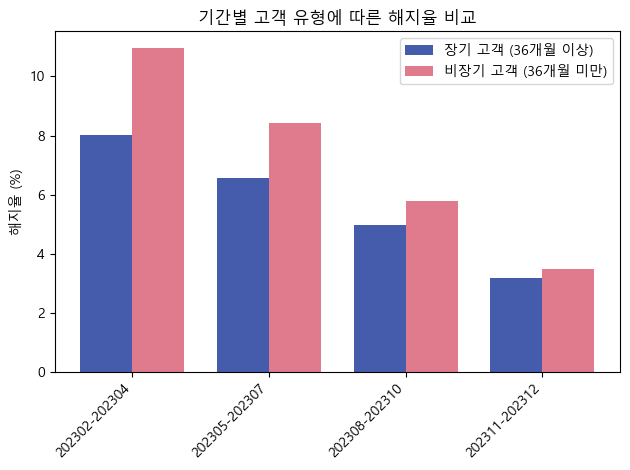

In [ ]:
# # 기간별 해지율 비교 (장기 VS 비장기)
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm
# import warnings
# warnings.filterwarnings('ignore')

# # 한글 폰트 설정 (Windows)
# font_path = 'C:/Windows/Fonts/malgun.ttf'
# font_prop = fm.FontProperties(fname=font_path)

# plt.rcParams['font.family'] = font_prop.get_name()
# plt.rcParams['axes.unicode_minus'] = False

# # 데이터 정렬
# plot_df = ok.sort_values("period").reset_index(drop=True)

# x = np.arange(len(plot_df))
# periods = plot_df["period"].tolist()
# w = 0.38

# # 🎨 색상 지정 (요청한 조합)
# colors = ["#455BAC", "#E07A8D"]  # 네이비 / 더스티 핑크

# plt.figure()
# plt.bar(
#     x - w/2,
#     plot_df["cancel_rate_long_%"],
#     width=w,
#     label="장기 고객 (36개월 이상)",
#     color=colors[0]
# )
# plt.bar(
#     x + w/2,
#     plot_df["cancel_rate_others_%"],
#     width=w,
#     label="비장기 고객 (36개월 미만)",
#     color=colors[1]
# )

# plt.xticks(x, periods, rotation=45, ha="right")
# plt.ylabel("해지율 (%)")
# plt.title("기간별 고객 유형에 따른 해지율 비교")
# plt.legend()
# plt.tight_layout()
# plt.show()


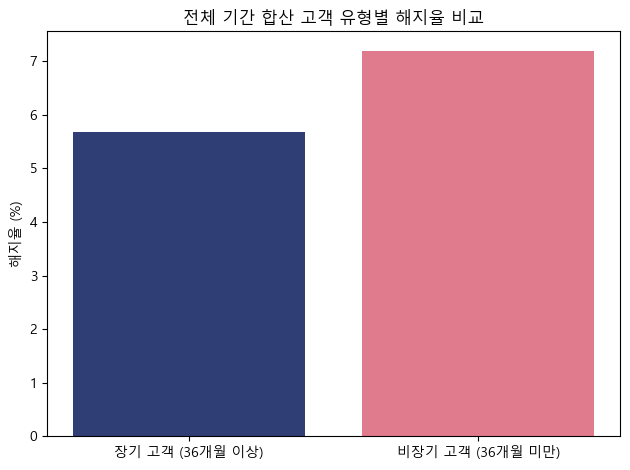

In [18]:
# =========================
# 전체 기간 합산 (고객 단위)
# =========================

total_long_canceled   = ok["long_canceled"].sum()
total_long_not        = ok["long_not_canceled"].sum()

total_oth_canceled    = ok["others_canceled"].sum()
total_oth_not         = ok["others_not_canceled"].sum()

# 해지율 (%)
rate_long_total = total_long_canceled / (total_long_canceled + total_long_not) * 100
rate_oth_total  = total_oth_canceled  / (total_oth_canceled  + total_oth_not)  * 100

rate_long_total, rate_oth_total
labels = ["장기 고객 (36개월 이상)", "비장기 고객 (36개월 미만)"]
rates  = [rate_long_total, rate_oth_total]

colors = ["#2F3E75", "#E07A8D"]

plt.figure()
plt.bar(labels, rates, color=colors)

plt.ylabel("해지율 (%)")
plt.title("전체 기간 합산 고객 유형별 해지율 비교")
plt.tight_layout()
plt.show()


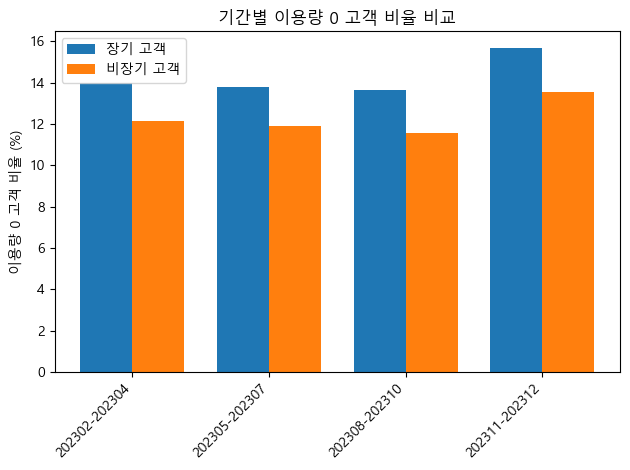

In [8]:
#기간별 ‘이용량 0’ 고객 비율 비교
plt.figure()
plt.bar(x - w/2, plot_df["zero_use_rate_long_%"], width=w, label="장기 고객")
plt.bar(x + w/2, plot_df["zero_use_rate_others_%"], width=w, label="비장기 고객")

plt.xticks(x, periods, rotation=45, ha="right")
plt.ylabel("이용량 0 고객 비율 (%)")
plt.title("기간별 이용량 0 고객 비율 비교")
plt.legend()
plt.tight_layout()
plt.show()


In [3]:
import numpy as np
from scipy.stats import chi2_contingency

# =========================
# 1) 정상 행만 사용 (에러 행 제거)
# =========================
df_sum = summary.copy()
if "error" in df_sum.columns:
    df_sum = df_sum[df_sum["error"].isna()].copy()

# =========================
# 2) 기간별 값을 모두 합산
# =========================
total_long_canceled   = df_sum["long_canceled"].sum()
total_long_total      = df_sum["n_long"].sum()

total_others_canceled = df_sum["others_canceled"].sum()
total_others_total    = df_sum["n_others"].sum()

# =========================
# 3) 총합 해지율 계산
# =========================
total_rate_long   = total_long_canceled / total_long_total
total_rate_others = total_others_canceled / total_others_total

diff_pp_total = (total_rate_long - total_rate_others) * 100
relative_reduction_total = (total_rate_others - total_rate_long) / total_rate_others * 100

# =========================
# 4) 총합 2x2 테이블 + 카이제곱
# =========================
ct_total = np.array([
    [total_others_total - total_others_canceled, total_others_canceled],
    [total_long_total   - total_long_canceled,   total_long_canceled]
])

chi2, p_value, dof, exp = chi2_contingency(ct_total)

# =========================
# 5) 결과 출력
# =========================
print("=== 전체 기간 통합 결과 (고객 단위) ===")
print("2x2 table (grp_long x cancel_yn)")
print(f"Others(<36m): NotCanceled={ct_total[0,0]}, Canceled={ct_total[0,1]}")
print(f"Long(36m+):   NotCanceled={ct_total[1,0]}, Canceled={ct_total[1,1]}\n")

print(f"Long cancel rate:   {total_rate_long:.4%}")
print(f"Others cancel rate: {total_rate_others:.4%}")
print(f"Diff: {diff_pp_total:.3f} %p")
print(f"Relative reduction: {relative_reduction_total:.2f} %")
print(f"Chi-square p-value: {p_value:.3g}")


=== 전체 기간 통합 결과 (고객 단위) ===
2x2 table (grp_long x cancel_yn)
Others(<36m): NotCanceled=2345986, Canceled=181970
Long(36m+):   NotCanceled=5410135, Canceled=325818

Long cancel rate:   5.6803%
Others cancel rate: 7.1983%
Diff: -1.518 %p
Relative reduction: 21.09 %
Chi-square p-value: 0
